# Device-calibration transition — priors vs structure on the [[72,4,8]] channels

**The convention change (2026-07-31, commits 3916611b/da2ae43d):** the legacy campaign
calibrated each error-model task's decoder priors on that task's OWN noise model — so
"meas only" was decoded by a decoder that believed only measurement errors exist. That
specialist is not the device's decoder, and the per-channel rows never answered the
error-budget question. Under `EMC_CALIB=device` every model and ablation of a code is
decoded by ONE decoder calibrated on the full-symmetric circuit at p* = 5e-4 (the ×5
asym rays keep their own full-asym device decoder). The legacy sub-model results were
retired to `runs/_retired_permodel_calib/` — kept only so this notebook can measure the
priors effect by differencing.

**Reading:** same circuits, same sampling — every device-vs-specialist difference below
is purely the decoder's priors. |z| > 2 marks real effects. Bins deepen as the rodan
device campaign + specimen top-up merge in; re-execute to tighten.

In [1]:
from emc_report import DevTransition
D = DevTransition()
D.load()

loaded 5 channels x (device, specialist) + full-sym anchors; 0/5 device channels have top-up bins so far


## 1. Channel spectra — specialist (retired) vs device decoder

First finding (generation-depth bins): the priors effect is channel-dependent, and it
moves the error budget's ordering — **gate idle** decodes 2–3× BETTER under the device
decoder (cross-channel context helps; the legacy data overstated its budget share),
while **meas idle** decodes 2–6× WORSE (it genuinely benefited from specialist priors;
the legacy data understated it). CZ and prep show no priors effect.

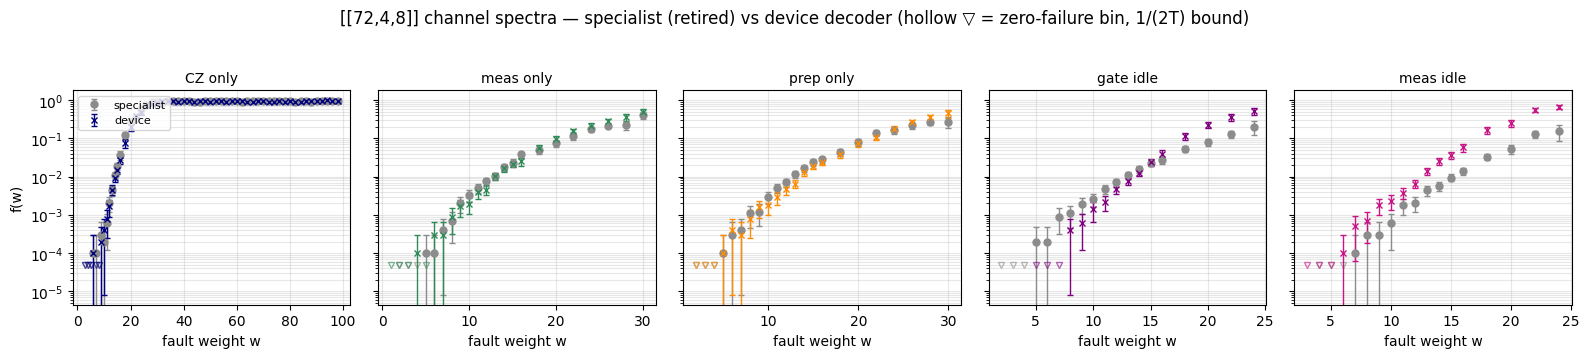

In [2]:
D.fig_channels()

In [3]:
D.ratio_table()

channel        w         device     specialist   ratio      z
CZ only        6      1/10000         1/10000      1.00    0.0
CZ only        7      0/10000         1/10000      n/a    -0.7
CZ only        9      2/10000         3/10000      0.67   -0.4
CZ only       10      4/10000         2/10000      2.00    0.8
CZ only       11      8/10000         6/10000      1.33    0.5
CZ only       12     17/10000        21/10000      0.81   -0.6
CZ only       13     46/10000        45/10000      1.02    0.1
CZ only       14     90/10000       103/9350       0.82   -1.4
CZ only       15     88/5931         80/4185       0.78   -1.6
CZ only       16     78/2817         48/1277       0.74   -1.6
CZ only       18     54/722          64/533        0.62   -2.5
CZ only       20     77/382         116/411        0.71   -2.3
CZ only       22     95/253          73/209        1.08    0.5
CZ only       24     71/147          81/140        0.83   -1.1
CZ only       26    100/137          85/110        0.94 

## 2. Full-symmetric anchors (convention-invariant)

The full-symmetric model calibrates on itself under BOTH conventions, so the headline
decoder results carry over unchanged: the measured-vs-measured spectra (3e6-shot top-up
bins, w = 2–10 both decoders) and the reweighted LER at p*.

In [4]:
D.anchor_table()

full-symmetric [[72,4,8]] anchors at p* = 0.0005 (convention-invariant):
  baseline : LER = 1.408e-06 ± 1.8e-07   zero-bin headroom +18%
  ghw      : LER = 1.421e-07 ± 4.9e-08   zero-bin headroom +179%
  decoder improvement: 9.9x  (floor 3.6x pricing every ghw zero bin at 3/T)


## 3. What re-executes as data lands

* **Device campaign** (rodan `emc_device_s*`): ablations + asym under the device
  decoder — the error-budget sections of the main report regenerate from that dir.
* **Specimen top-up** (`run_sys_topup.sh` on the device dir): deepens the w = 2–10
  channel bins to the 3e6 cap AND records failing mechanism configurations
  (`failure_configs`, ≤200/weight). Under the device convention a sub-model failing
  config IS a full-model failing config — specimens feed the decoder-loop library
  directly (`add_w3_harvest_to_library.py` pattern).
* This notebook's §1 ratios tighten automatically on re-execution; the main report
  copy against the device dir is the final deliverable once the campaign completes.